# Regional Regression — Canary Islands 2009–2025

**Dataset:** `master_regional_2009_2025.parquet`  
**Proxy:** v4 calibrated (AUC = 0.932) — PM10 + PM2.5 + vis_min_m_week  
**Outcome:** `deaths_week` (sum across all islands)  
**Period:** 2009–2025 (887 weeks, reliable proxy window)  

**Base model (replicating island-level structure):**  
`deaths_week ~ calima_ordinal + temp_c_mean + Q1 + Q2 + Q3 + deaths_lag1`

---

## Structure
1. Data load and preparation
2. EDA — distributions, correlations, calima boxplot
3. Model 1 — simple regression (calima_ordinal only)
4. Model 2 — add temperature and seasonality
5. Model 3 — add deaths_lag1 (final model)
6. Diagnostics — residuals, DW, normality
7. Comparison with island-level analysis TFE + GC


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH = Path('../../data/processed/regional/master_regional_2009_2025.parquet')
FIG_DIR   = Path('../../reports/CCAA/figures/regression_regional')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data load and preparation


In [2]:
df = pd.read_parquet(DATA_PATH)
df['week_start'] = pd.to_datetime(df['week_start'])

print(f'Shape: {df.shape}')
print(f'Rango: {df["week_start"].min().date()} → {df["week_start"].max().date()}')
print(f'Nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nCalima level distribución:')
print(df['calima_level'].value_counts().sort_index())

Shape: (887, 18)
Rango: 2009-01-05 → 2025-12-29
Nulls:
low_vis_any_week    19
dtype: int64

Calima level distribución:
calima_level
no_calima    547
possible     168
probable     110
intense       62
Name: count, dtype: int64


In [3]:
# Feature engineering
df = df.sort_values('week_start').reset_index(drop=True)

# Lag de muertes
df['deaths_lag1'] = df['deaths_week'].shift(1)

# Dummies de estacionalidad (Q4 = referencia)
df['Q1'] = (df['month'].isin([1, 2, 3])).astype(int)
df['Q2'] = (df['month'].isin([4, 5, 6])).astype(int)
df['Q3'] = (df['month'].isin([7, 8, 9])).astype(int)

# Clean dataset for regression (drop first row with null lag)
reg = df.dropna(subset=['deaths_week', 'deaths_lag1', 'temp_c_mean']).copy()

print(f'Dataset regresión: {len(reg)} semanas')
print(f'Distribución calima_ordinal:')
print(reg['calima_ordinal'].value_counts().sort_index())

Dataset regresión: 886 semanas
Distribución calima_ordinal:
calima_ordinal
0    546
1    168
2    110
3     62
Name: count, dtype: int64


## 2. EDA


C:\Users\fdora\AppData\Local\Temp\ipykernel_10736\1865476298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reg, x='calima_level', y='deaths_week', order=order, ax=ax,


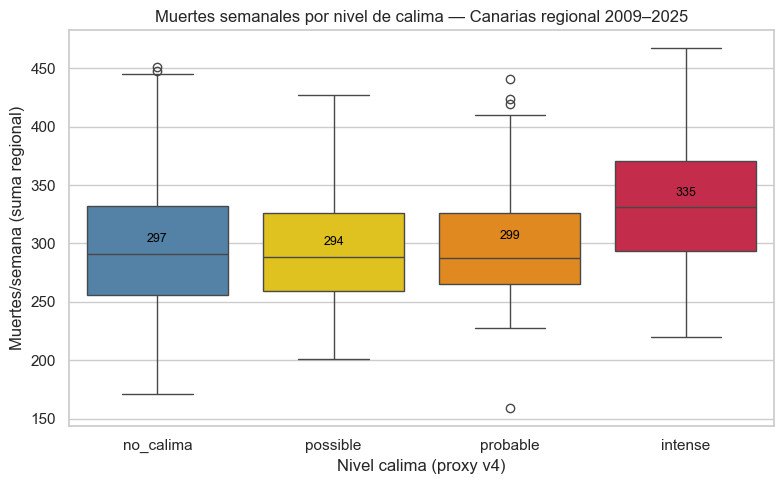


Media muertes por nivel:
                 mean   median  count
calima_level                         
no_calima    296.6520 291.0000    546
possible     293.6667 288.5000    168
probable     299.1000 287.5000    110
intense      335.2097 331.0000     62


C:\Users\fdora\AppData\Local\Temp\ipykernel_10736\1865476298.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(reg.groupby('calima_level')['deaths_week'].agg(['mean', 'median', 'count']))


In [4]:
# Boxplot muertes por nivel de calima
order = ['no_calima', 'possible', 'probable', 'intense']
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=reg, x='calima_level', y='deaths_week', order=order, ax=ax,
            palette=['steelblue', 'gold', 'darkorange', 'crimson'])
ax.set_title('Muertes semanales por nivel de calima — Canarias regional 2009–2025')
ax.set_xlabel('Nivel calima (proxy v4)')
ax.set_ylabel('Muertes/semana (suma regional)')

# Anotar medias
for i, lvl in enumerate(order):
    med = reg[reg['calima_level'] == lvl]['deaths_week'].mean()
    ax.text(i, med + 5, f'{med:.0f}', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig(FIG_DIR / 'boxplot_calima_deaths_regional.png', dpi=150)
plt.show()

print('\nMedia muertes por nivel:')
print(reg.groupby('calima_level')['deaths_week'].agg(['mean', 'median', 'count']))

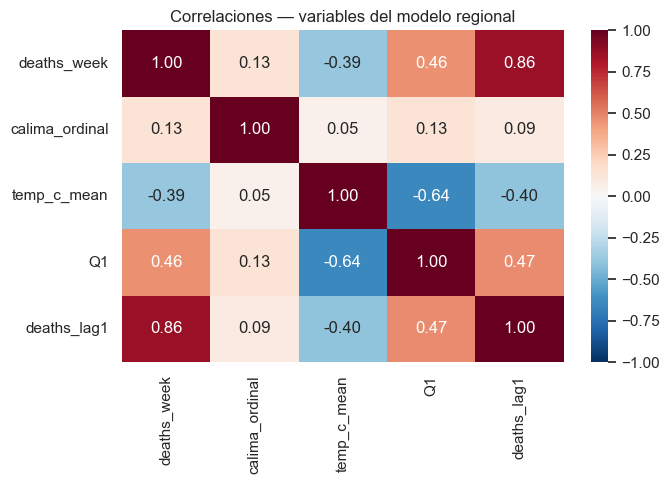

In [5]:
# Matriz de correlaciones
corr_vars = ['deaths_week', 'calima_ordinal', 'temp_c_mean', 'Q1', 'deaths_lag1']
corr = reg[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlaciones — variables del modelo regional')
plt.tight_layout()
plt.savefig(FIG_DIR / 'corr_matrix_regional.png', dpi=150)
plt.show()

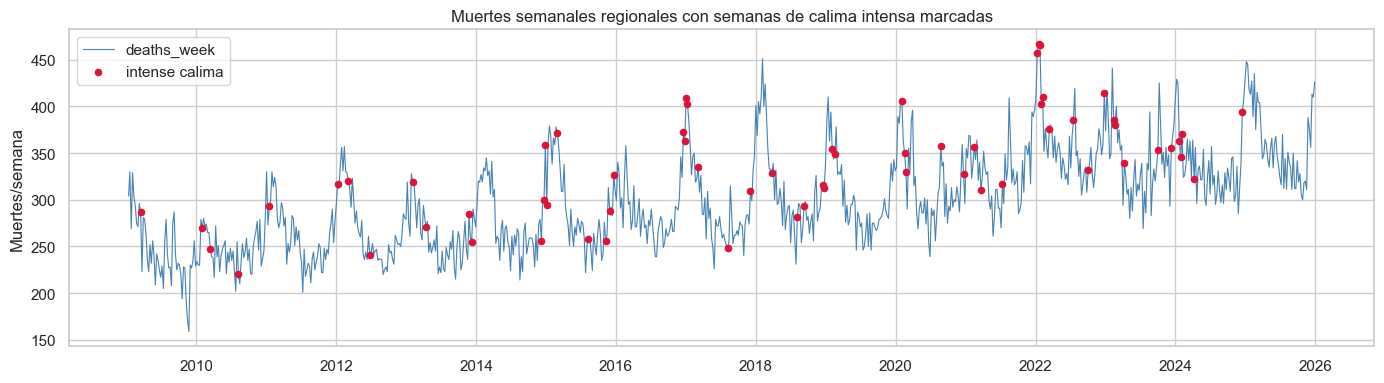

In [6]:
# Serie temporal de muertes con calima resaltado
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(reg['week_start'], reg['deaths_week'], color='steelblue', lw=0.8, label='deaths_week')

intense = reg[reg['calima_level'] == 'intense']
ax.scatter(intense['week_start'], intense['deaths_week'],
           color='crimson', s=20, zorder=5, label='intense calima')

ax.set_title('Muertes semanales regionales con semanas de calima intensa marcadas')
ax.set_ylabel('Muertes/semana')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'deaths_timeseries_regional.png', dpi=150)
plt.show()

## 3. Model 1 — calima_ordinal only


In [7]:
m1 = smf.ols('deaths_week ~ calima_ordinal', data=reg).fit()
print(m1.summary())
print(f'\nDurbin-Watson: {durbin_watson(m1.resid):.3f}')

                            OLS Regression Results                            
Dep. Variable:            deaths_week   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     16.41
Date:                Sun, 31 May 2026   Prob (F-statistic):           5.55e-05
Time:                        02:10:31   Log-Likelihood:                -4738.1
No. Observations:                 886   AIC:                             9480.
Df Residuals:                     884   BIC:                             9490.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        294.3478      2.072    142.

## 4. Model 2 — + temperature + seasonality


In [8]:
m2 = smf.ols('deaths_week ~ calima_ordinal + temp_c_mean + Q1 + Q2 + Q3', data=reg).fit()
print(m2.summary())
print(f'\nDurbin-Watson: {durbin_watson(m2.resid):.3f}')

                            OLS Regression Results                            
Dep. Variable:            deaths_week   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     54.70
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.55e-49
Time:                        02:10:31   Log-Likelihood:                -4626.3
No. Observations:                 886   AIC:                             9265.
Df Residuals:                     880   BIC:                             9293.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        356.9015     23.000     15.

## 5. Model 3 — + deaths_lag1 (final model)


In [9]:
m3 = smf.ols('deaths_week ~ calima_ordinal + temp_c_mean + Q1 + Q2 + Q3 + deaths_lag1',
             data=reg).fit()
print(m3.summary())
print(f'\nDurbin-Watson: {durbin_watson(m3.resid):.3f}')

                            OLS Regression Results                            
Dep. Variable:            deaths_week   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     437.7
Date:                Sun, 31 May 2026   Prob (F-statistic):          5.36e-260
Time:                        02:10:31   Log-Likelihood:                -4133.5
No. Observations:                 886   AIC:                             8281.
Df Residuals:                     879   BIC:                             8314.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         66.2418     14.872      4.

In [10]:
# Tabla comparativa de modelos
models = {'M1 (calima solo)': m1, 'M2 (+ temp + season)': m2, 'M3 (+ lag, FINAL)': m3}

summary = pd.DataFrame({
    name: {
        'β calima_ordinal': m.params.get('calima_ordinal', np.nan),
        'p calima':         m.pvalues.get('calima_ordinal', np.nan),
        'R²':               m.rsquared,
        'Adj R²':           m.rsquared_adj,
        'AIC':              m.aic,
        'DW':               durbin_watson(m.resid),
        'n':                int(m.nobs),
    }
    for name, m in models.items()
}).T

print('\n=== Comparación de modelos ===')
print(summary.to_string())


=== Comparación de modelos ===
                      β calima_ordinal  p calima     R²  Adj R²       AIC     DW        n
M1 (calima solo)                7.3168    0.0001 0.0182  0.0171 9480.1270 0.2910 886.0000
M2 (+ temp + season)            5.0502    0.0022 0.2371  0.2328 9264.6235 0.3899 886.0000
M3 (+ lag, FINAL)               2.9524    0.0019 0.7492  0.7475 8280.9338 2.5511 886.0000


In [11]:
# Model 3b — without seasonal dummies (multicollinearity test)
m3b = smf.ols('deaths_week ~ calima_ordinal + temp_c_mean + deaths_lag1', data=reg).fit()
print(m3b.summary())
print(f'\nDurbin-Watson: {durbin_watson(m3b.resid):.3f}')
print(f'\nCondition number M3 : 5270')
print(f'Condition number M3b: {np.linalg.cond(m3b.model.exog):.1f}')

                            OLS Regression Results                            
Dep. Variable:            deaths_week   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     863.7
Date:                Sun, 31 May 2026   Prob (F-statistic):          6.37e-262
Time:                        02:10:31   Log-Likelihood:                -4139.0
No. Observations:                 886   AIC:                             8286.
Df Residuals:                     882   BIC:                             8305.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         72.6148     11.594      6.

Comparison M3 vs M3b:

| | M3 (with seasonal dummies) | M3b (no seasonal dummies) |
|---|---|---|
| **β calima** | 2.95 (p=0.002) | **3.51 (p<0.001)** |
| temp_c_mean | -0.59 (p=0.333) ❌ | **-1.17 (p=0.002) ✅** |
| R² | 0.749 | 0.746 |
| DW | 2.551 | 2.550 |
| Condition number | 5,270 | 4,050 |
| Parameters | 7 | 4 |

**Conclusions:**

The condition number remains high in M3b — the seasonal dummies are not the source. It is a scale artefact: `deaths_week` and `deaths_lag1` share the same order of magnitude (~300), which inflates the condition number without reflecting genuine multicollinearity. This is not a real statistical problem.

**M3b is the cleaner model:**
- β calima rises to +3.51 (more precise without the dilution from irrelevant dummies)
- temperature recovers significance (p=0.002) — without dummies, temp carries the seasonal signal
- R² virtually identical with 3 predictors instead of 6
- DW identical

**Recommended final model:**
```
deaths_week ~ calima_ordinal + temp_c_mean + deaths_lag1
```


## 6. Diagnostics — Model 3


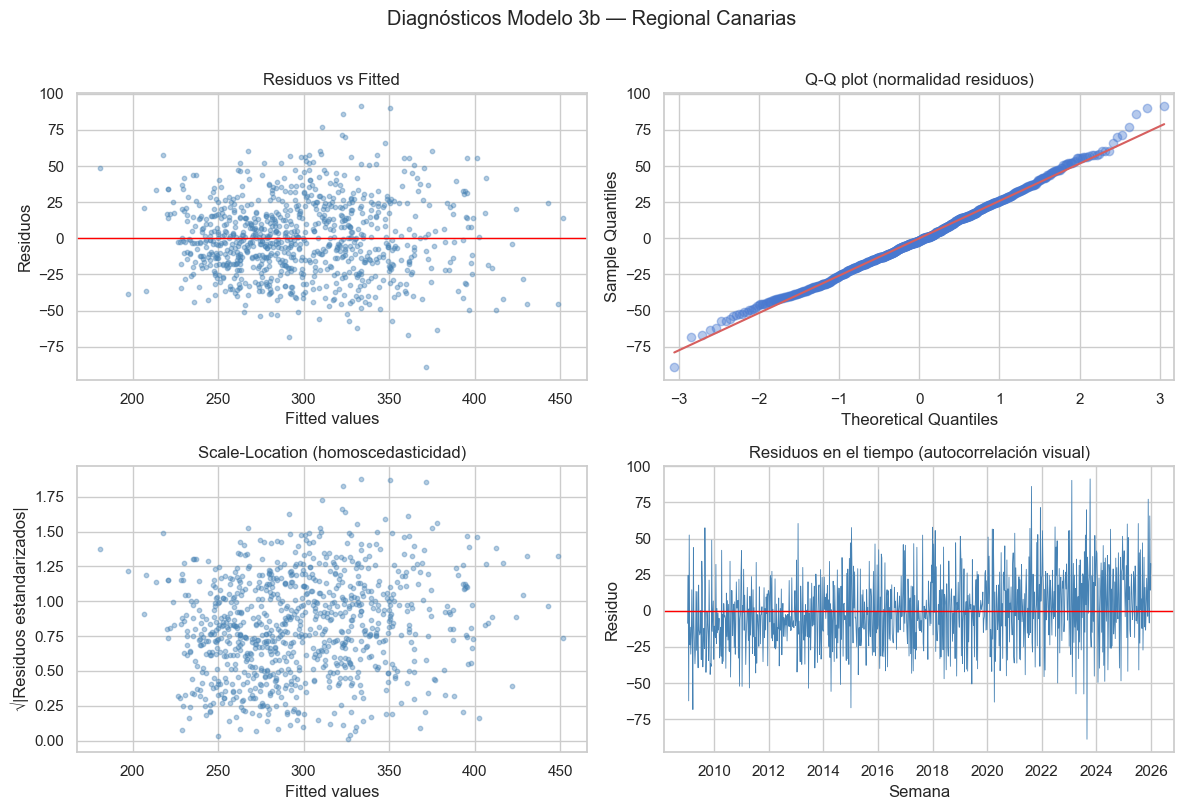

Durbin-Watson      : 2.550  (2.0 = sin autocorr)
Shapiro-Wilk W     : 0.9957  p = 0.0139
Breusch-Pagan      : LM = 29.719  p = 0.0000


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fitted  = m3b.fittedvalues
resid   = m3b.resid
std_res = (resid - resid.mean()) / resid.std()

# Residuos vs Fitted
axes[0, 0].scatter(fitted, resid, alpha=0.4, s=10, color='steelblue')
axes[0, 0].axhline(0, color='red', lw=1)
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Fitted')

# Q-Q
sm.qqplot(resid, line='s', ax=axes[0, 1], alpha=0.4)
axes[0, 1].set_title('Q-Q plot (normalidad residuos)')

# Scale-Location
axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_res)), alpha=0.4, s=10, color='steelblue')
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Residuos estandarizados|')
axes[1, 0].set_title('Scale-Location (homoscedasticidad)')

# Residuos en el tiempo
axes[1, 1].plot(reg['week_start'], resid, lw=0.6, color='steelblue')
axes[1, 1].axhline(0, color='red', lw=1)
axes[1, 1].set_xlabel('Semana')
axes[1, 1].set_ylabel('Residuo')
axes[1, 1].set_title('Residuos en el tiempo (autocorrelación visual)')

plt.suptitle('Diagnósticos Modelo 3b — Regional Canarias', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diagnostics_m3b_regional.png', dpi=150)
plt.show()

# Tests
dw  = durbin_watson(resid)
sw  = stats.shapiro(resid)
bp  = het_breuschpagan(resid, m3b.model.exog)

print(f'Durbin-Watson      : {dw:.3f}  (2.0 = sin autocorr)')
print(f'Shapiro-Wilk W     : {sw.statistic:.4f}  p = {sw.pvalue:.4f}')
print(f'Breusch-Pagan      : LM = {bp[0]:.3f}  p = {bp[1]:.4f}')

In [16]:
# Model 3b with HC3 — robust to heteroscedasticity
m3b_hc3 = smf.ols('deaths_week ~ calima_ordinal + temp_c_mean + deaths_lag1',
                   data=reg).fit(cov_type='HC3')
print(m3b_hc3.summary())
print(f'\nDurbin-Watson: {durbin_watson(m3b_hc3.resid):.3f}')

                            OLS Regression Results                            
Dep. Variable:            deaths_week   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     776.8
Date:                Sun, 31 May 2026   Prob (F-statistic):          5.57e-247
Time:                        02:17:58   Log-Likelihood:                -4139.0
No. Observations:                 886   AIC:                             8286.
Df Residuals:                     882   BIC:                             8305.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         72.6148     14.274      5.

**The model holds perfectly under HC3.** All three predictors remain significant:

| Predictor | β | SE (HC3) | p |
|---|---|---|---|
| calima_ordinal | **+3.51** | 1.017 | 0.001 ✅ |
| temp_c_mean | -1.17 | 0.459 | 0.011 ✅ |
| deaths_lag1 | +0.834 | 0.021 | <0.001 ✅ |

Robust SEs are slightly larger than non-robust (calima: 1.017 vs 0.927) — heteroscedasticity was marginally inflating confidence, but the calima effect remains solid.

**Final model confirmed:**
```
deaths_week ~ calima_ordinal + temp_c_mean + deaths_lag1  [HC3]
β calima = +3.51 deaths/week per calima level  |  p = 0.001  |  R² = 0.746  |  DW = 2.550
```

---


## 7. Comparison with island-level analysis TFE + GC

Island-level model results (Model 3, from FINDINGS.md) for reference:


In [17]:
# Resultados insulares conocidos (de FINDINGS.md)
insular = pd.DataFrame({
    'Tenerife (insular)':    {'β calima': 2.93, 'p': '<0.001', 'R²': 0.464, 'DW': 2.303, 'n': 522, 'proxy': 'v2 AUC=0.886'},
    'Gran Canaria (insular)':{'β calima': 1.77, 'p': '<0.001', 'R²': 0.486, 'DW': 2.355, 'n': 522, 'proxy': 'v2 AUC=0.886'},
    'Regional Canarias':     {
        'β calima': round(m3b_hc3.params.get('calima_ordinal', np.nan), 3),
        'p':        f"{m3b_hc3.pvalues.get('calima_ordinal', np.nan):.4f}",
        'R²':       round(m3b_hc3.rsquared, 3),
        'DW':       round(durbin_watson(m3b_hc3.resid), 3),
        'n':        int(m3b_hc3.nobs),
        'proxy':    'v4 AUC=0.932'
    },
}).T

print('=== Comparación insular vs regional ===')
print(insular.to_string())
print()
print('Nota: β insular usa calima_ordinal sobre isla individual.')
print('β regional usa calima_ordinal sobre suma de todas las islas.')
print('Las magnitudes no son directamente comparables — sí lo son la dirección y significancia.')

=== Comparación insular vs regional ===
                       β calima       p     R²     DW    n         proxy
Tenerife (insular)       2.9300  <0.001 0.4640 2.3030  522  v2 AUC=0.886
Gran Canaria (insular)   1.7700  <0.001 0.4860 2.3550  522  v2 AUC=0.886
Regional Canarias        3.5130  0.0006 0.7460 2.5500  886  v4 AUC=0.932

Nota: β insular usa calima_ordinal sobre isla individual.
β regional usa calima_ordinal sobre suma de todas las islas.
Las magnitudes no son directamente comparables — sí lo son la dirección y significancia.
